# Hulu-Med closed-question analysis

This notebook analyzes **Hulu-Med** on **SLAKE closed (Yes/No) questions** using the **raw closed files**.

The analysis focuses on prompt sensitivity, consensus vs non-consensus behavior, single vs multi prompting, emotion effects, role effects, and direct-vs-indirect phrasing effects.


In [1]:

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

MODEL_PREFIX = "hulumed"
INPUT_DIR = Path("output/phase_2/Hulu-Med")
DATASET = "SLAKE"
ONLY_CLOSED = True

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)


In [2]:

def parse_answer(text):
    if text is None:
        return "Undecided"

    text = str(text).strip()
    text_lower = text.lower()

    if text.startswith("Yes"):
        return "Yes"
    if text.startswith("No"):
        return "No"

    has_yes = "yes" in text_lower
    has_no = "no" in text_lower

    if has_yes and has_no:
        return "Undecided"
    if has_yes:
        return "Yes"
    if has_no:
        return "No"
    return "Undecided"


def compute_metrics(preds, gts):
    yes = sum(p == "Yes" for p in preds)
    no = sum(p == "No" for p in preds)
    undecided = sum(p == "Undecided" for p in preds)

    tp = sum((p == "Yes") and (g == "Yes") for p, g in zip(preds, gts))
    fp = sum((p == "Yes") and (g == "No") for p, g in zip(preds, gts))
    tn = sum((p == "No") and (g == "No") for p, g in zip(preds, gts))
    fn = sum((p == "No") and (g == "Yes") for p, g in zip(preds, gts))

    total_valid = yes + no
    acc = (tp + tn) / total_valid if total_valid else 0.0

    return {
        "yes": yes,
        "no": no,
        "undecided": undecided,
        "tp": tp,
        "fp": fp,
        "tn": tn,
        "fn": fn,
        "acc": acc,
        "total": len(preds),
    }


def parse_prefix(prefix):
    name = prefix.replace("eval_", "")
    core = name[len("hulumed_"):]
    core = core[:-len("_closed")] if core.endswith("_closed") else core

    parts = core.split("_")
    dataset = parts[0]
    conv_mode = parts[1]
    emotion = "_".join(parts[2:])

    return {
        "dataset": dataset,
        "conv_mode": conv_mode,
        "emotion": emotion,
    }


label_map = {
    "default": "default",
    "direct_clinician_neutral": "clin_neutral_dir",
    "direct_clinician_fear_anxiety": "clin_fear_dir",
    "direct_clinician_anger_frustration": "clin_anger_dir",
    "direct_clinician_sadness_distress": "clin_sad_dir",
    "direct_patient_neutral": "pat_neutral_dir",
    "direct_patient_fear_anxiety": "pat_fear_dir",
    "direct_patient_anger_frustration": "pat_anger_dir",
    "direct_patient_sadness_distress": "pat_sad_dir",
    "indirect_clinician_neutral": "clin_neutral_Indir",
    "indirect_clinician_fear_anxiety": "clin_fear_Indir",
    "indirect_clinician_anger_frustration": "clin_anger_Indir",
    "indirect_clinician_sadness_distress": "clin_sad_Indir",
    "indirect_patient_neutral": "pat_neutral_Indir",
    "indirect_patient_fear_anxiety": "pat_fear_Indir",
    "indirect_patient_anger_frustration": "pat_anger_Indir",
    "indirect_patient_sadness_distress": "pat_sad_Indir",
}

emotion_short_map = {
    "neutral": "neutral",
    "fear_anxiety": "fear",
    "anger_frustration": "anger",
    "sadness_distress": "sad",
    "default": "default",
}


def prompt_style(emotion):
    if emotion == "default":
        return "default"
    return "direct" if emotion.startswith("direct_") else "indirect"


def prompt_role(emotion):
    if emotion == "default":
        return "default"
    return "clinician" if "clinician" in emotion else "patient"


def prompt_emotion(emotion):
    if emotion == "default":
        return "default"
    return emotion_short_map["_".join(emotion.split("_")[2:])]


def yes_rate(yes, no):
    total = yes + no
    return yes / total if total else np.nan


def mean_off_diagonal(mat):
    vals = mat.astype(float).values
    n = vals.shape[0]
    off_diag = vals[~np.eye(n, dtype=bool)]
    return off_diag.mean()


def build_similarity_matrix(answer_df, columns):
    sim_matrix = pd.DataFrame(index=columns, columns=columns, dtype=float)

    for c1 in columns:
        a1 = answer_df[c1].tolist()
        for c2 in columns:
            a2 = answer_df[c2].tolist()
            m = len(a1)
            sim = sum(x == y for x, y in zip(a1, a2)) / m if m else 0.0
            sim_matrix.loc[c1, c2] = sim

    return sim_matrix


def plot_similarity_heatmap(mat, title, figsize=(10, 8), fontsize=8):
    plt.figure(figsize=figsize)
    plt.imshow(mat.astype(float), aspect="auto")
    plt.colorbar(label="Similarity")

    plt.xticks(
        ticks=range(len(mat.columns)),
        labels=mat.columns,
        rotation=90,
    )
    plt.yticks(
        ticks=range(len(mat.index)),
        labels=mat.index,
    )

    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            val = mat.iloc[i, j]
            plt.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=fontsize)

    plt.title(title)
    plt.tight_layout()
    plt.show()


def get_metric(wide_df, prompt, column):
    return float(wide_df.loc[wide_df["prompt"] == prompt, column].iloc[0])


row_order = [
    "default",
    "clin_neutral_dir",
    "clin_fear_dir",
    "clin_anger_dir",
    "clin_sad_dir",
    "pat_neutral_dir",
    "pat_fear_dir",
    "pat_anger_dir",
    "pat_sad_dir",
    "clin_neutral_Indir",
    "clin_fear_Indir",
    "clin_anger_Indir",
    "clin_sad_Indir",
    "pat_neutral_Indir",
    "pat_fear_Indir",
    "pat_anger_Indir",
    "pat_sad_Indir",
]


In [3]:

rows = []
all_preds = {}
all_gts = None

pattern = f"{MODEL_PREFIX}_{DATASET}_*_closed.jsonl" if ONLY_CLOSED else f"{MODEL_PREFIX}_{DATASET}_*.jsonl"

for file in sorted(INPUT_DIR.glob(pattern)):
    if file.name.startswith("eval_"):
        continue

    preds = []
    gts = []

    with open(file, "r", encoding="utf-8") as f:
        for line in f:
            item = json.loads(line)
            preds.append(parse_answer(item["model_answer"]))
            gts.append(item["answer"])

    prefix = file.stem
    metrics = compute_metrics(preds, gts)
    metrics["prefix"] = prefix
    rows.append(metrics)

    all_preds[prefix] = preds
    if all_gts is None:
        all_gts = gts

result_df = pd.DataFrame(rows)
meta_df = pd.DataFrame([parse_prefix(x) for x in result_df["prefix"]])
result_df = pd.concat([meta_df, result_df], axis=1)
result_df["prompt"] = result_df["emotion"].map(label_map)
result_df["style"] = result_df["emotion"].apply(prompt_style)
result_df["role"] = result_df["emotion"].apply(prompt_role)
result_df["affect"] = result_df["emotion"].apply(prompt_emotion)

summary_df = result_df[["dataset", "conv_mode", "emotion", "prompt", "style", "role", "affect", "yes", "no", "acc"]].copy()
summary_df = summary_df.sort_values(["conv_mode", "emotion"]).reset_index(drop=True)

wide_table = summary_df.pivot(index="prompt", columns="conv_mode", values=["yes", "no", "acc"])
wide_table = wide_table.swaplevel(0, 1, axis=1)
wide_table = wide_table[
    [
        ("single", "yes"),
        ("single", "no"),
        ("multi", "yes"),
        ("multi", "no"),
        ("single", "acc"),
        ("multi", "acc"),
    ]
]
wide_table.columns = [
    "single_Yes", "single_No", "multi_Yes", "multi_No", "single_Acc", "multi_Acc"
]
wide_table = wide_table.reset_index()
wide_table["prompt"] = pd.Categorical(wide_table["prompt"], categories=row_order, ordered=True)
wide_table = wide_table.sort_values("prompt").reset_index(drop=True)
wide_table["single_Acc"] = wide_table["single_Acc"].round(3)
wide_table["multi_Acc"] = wide_table["multi_Acc"].round(3)

print(f"Loaded {len(result_df)} prompt files.")
print(f"Samples per file: {result_df['total'].iloc[0]}")
wide_table


Loaded 33 prompt files.
Samples per file: 355


,prompt,single_Yes,single_No,multi_Yes,multi_No,single_Acc,multi_Acc
0,default,174.0,181.0,NaN,NaN,0.879,NaN
1,clin_neutral_dir,157.0,198.0,170.0,185.0,0.837,0.873
2,clin_fear_dir,145.0,210.0,179.0,176.0,0.808,0.859
3,clin_anger_dir,101.0,254.0,172.0,183.0,0.775,0.851
4,clin_sad_dir,122.0,233.0,176.0,179.0,0.811,0.856
5,pat_neutral_dir,162.0,193.0,182.0,173.0,0.834,0.862
6,pat_fear_dir,151.0,204.0,182.0,173.0,0.808,0.856
7,pat_anger_dir,130.0,225.0,185.0,170.0,0.794,0.859
8,pat_sad_dir,143.0,212.0,183.0,172.0,0.808,0.854
9,clin_neutral_Indir,170.0,185.0,178.0,177.0,0.738,0.856


## Basic prompt-level performance

The table above summarizes Hulu-Med performance on **SLAKE closed yes/no questions** across all prompt conditions.

Each row corresponds to one prompt variant, and the columns report:

- **single_Yes / single_No**: number of predicted Yes and No answers in **single-turn** mode
- **multi_Yes / multi_No**: number of predicted Yes and No answers in **multi-turn** mode
- **single_Acc / multi_Acc**: exact accuracy for each mode

Initial observations:

- **Multi-turn prompting is consistently more accurate** than single-turn prompting across all comparable prompt variants.
- **Single-turn prompts tend to lean more toward “No”**, while multi-turn prompts are generally more balanced.
- The **default** prompt exists only in **single-turn** mode, so its multi-turn values are empty by design.

This table provides the main per-prompt summary before moving to deeper analyses such as consensus, similarity, emotion effects, role effects, and direct-vs-indirect comparisons.


## Consensus vs non-consensus setup

The next cells isolate **non-consensus** samples, where not all prompt variants agree.


In [4]:

merged_df = None

for prefix, preds in all_preds.items():
    temp_df = pd.DataFrame({
        "sample_id": range(len(preds)),
        prefix: preds,
    })
    merged_df = temp_df if merged_df is None else merged_df.merge(temp_df, on="sample_id")

merged_df["ground_truth"] = all_gts
prompt_columns = [c for c in merged_df.columns if c not in ["sample_id", "ground_truth"]]
merged_df["consensus"] = merged_df[prompt_columns].nunique(axis=1) == 1

non_consensus_df = merged_df[~merged_df["consensus"]].copy()

rows_nc = []
for prefix in prompt_columns:
    preds_nc = non_consensus_df[prefix].tolist()
    gts_nc = non_consensus_df["ground_truth"].tolist()
    metrics = compute_metrics(preds_nc, gts_nc)
    metrics["prefix"] = prefix
    rows_nc.append(metrics)

non_consensus_metrics_df = pd.DataFrame(rows_nc)
meta_nc = pd.DataFrame([parse_prefix(x) for x in non_consensus_metrics_df["prefix"]])
non_consensus_metrics_df = pd.concat([meta_nc, non_consensus_metrics_df], axis=1)
non_consensus_metrics_df["prompt"] = non_consensus_metrics_df["emotion"].map(label_map)

nc_wide_table = non_consensus_metrics_df.pivot(index="prompt", columns="conv_mode", values=["yes", "no", "acc"])
nc_wide_table = nc_wide_table.swaplevel(0, 1, axis=1)
nc_wide_table = nc_wide_table[
    [
        ("single", "yes"),
        ("single", "no"),
        ("multi", "yes"),
        ("multi", "no"),
        ("single", "acc"),
        ("multi", "acc"),
    ]
]
nc_wide_table.columns = [
    "single_Yes", "single_No", "multi_Yes", "multi_No", "single_Acc", "multi_Acc"
]
nc_wide_table = nc_wide_table.reset_index()
nc_wide_table["prompt"] = pd.Categorical(nc_wide_table["prompt"], categories=row_order, ordered=True)
nc_wide_table = nc_wide_table.sort_values("prompt").reset_index(drop=True)
nc_wide_table["single_Acc"] = nc_wide_table["single_Acc"].round(3)
nc_wide_table["multi_Acc"] = nc_wide_table["multi_Acc"].round(3)

print("Total SLAKE closed samples:", len(merged_df))
print("Consensus samples:", int(merged_df["consensus"].sum()))
print("Non-consensus samples:", int((~merged_df["consensus"]).sum()))
print("Non-consensus ratio:", round((~merged_df["consensus"]).mean(), 3))

nc_wide_table


Total SLAKE closed samples: 355
Consensus samples: 178
Non-consensus samples: 177
Non-consensus ratio: 0.499


,prompt,single_Yes,single_No,multi_Yes,multi_No,single_Acc,multi_Acc
0,default,120.0,57.0,NaN,NaN,0.819,NaN
1,clin_neutral_dir,103.0,74.0,116.0,61.0,0.734,0.808
2,clin_fear_dir,91.0,86.0,125.0,52.0,0.678,0.780
3,clin_anger_dir,47.0,130.0,118.0,59.0,0.610,0.763
4,clin_sad_dir,68.0,109.0,122.0,55.0,0.684,0.774
5,pat_neutral_dir,108.0,69.0,128.0,49.0,0.729,0.785
6,pat_fear_dir,97.0,80.0,128.0,49.0,0.678,0.774
7,pat_anger_dir,76.0,101.0,131.0,46.0,0.650,0.780
8,pat_sad_dir,89.0,88.0,129.0,48.0,0.678,0.768
9,clin_neutral_Indir,116.0,61.0,124.0,53.0,0.537,0.774


## Consensus vs non-consensus

To better understand prompt sensitivity, we separate the samples into:

- **Consensus samples**: all prompt variants give the same Yes/No answer
- **Non-consensus samples**: at least two prompt variants disagree

For Hulu-Med on **SLAKE closed questions**:

- Total samples: **355**
- Consensus samples: **178**
- Non-consensus samples: **177**
- Non-consensus ratio: **0.499**

Interpretation:

- Almost half of the closed SLAKE samples are **non-consensus**, which means Hulu-Med is substantially affected by prompt variation on these questions.
- These **non-consensus samples** are the most informative subset for studying emotional perturbation, because they reveal where different prompt conditions actually change model behavior.
- The later similarity and emotion analyses therefore focus heavily on this subset.


## Single vs multi prompting

This section compares the two conversation formats directly.


In [5]:

sim_matrix_nc = build_similarity_matrix(non_consensus_df, prompt_columns)

single_prefixes = [p for p in prompt_columns if "_single_" in p]
multi_prefixes = [p for p in prompt_columns if "_multi_" in p]

prefix_to_short = {prefix: label_map[parse_prefix(prefix)["emotion"]] for prefix in prompt_columns}

single_sim_matrix_nc = sim_matrix_nc.loc[single_prefixes, single_prefixes].copy()
single_sim_matrix_nc.index = [prefix_to_short[p] for p in single_sim_matrix_nc.index]
single_sim_matrix_nc.columns = [prefix_to_short[p] for p in single_sim_matrix_nc.columns]
single_sim_matrix_nc = single_sim_matrix_nc.loc[row_order, row_order]

multi_row_order = [x for x in row_order if x != "default"]
multi_sim_matrix_nc = sim_matrix_nc.loc[multi_prefixes, multi_prefixes].copy()
multi_sim_matrix_nc.index = [prefix_to_short[p] for p in multi_sim_matrix_nc.index]
multi_sim_matrix_nc.columns = [prefix_to_short[p] for p in multi_sim_matrix_nc.columns]
multi_sim_matrix_nc = multi_sim_matrix_nc.loc[multi_row_order, multi_row_order]

single_sim_matrix_nc.head()


,default,clin_neutral_dir,clin_fear_dir,clin_anger_dir,clin_sad_dir,pat_neutral_dir,pat_fear_dir,pat_anger_dir,pat_sad_dir,clin_neutral_Indir,clin_fear_Indir,clin_anger_Indir,clin_sad_Indir,pat_neutral_Indir,pat_fear_Indir,pat_anger_Indir,pat_sad_Indir
default,1.000000,0.813559,0.790960,0.576271,0.694915,0.819209,0.790960,0.706215,0.779661,0.581921,0.757062,0.621469,0.621469,0.604520,0.762712,0.536723,0.661017
clin_neutral_dir,0.813559,1.000000,0.864407,0.683616,0.790960,0.960452,0.819209,0.779661,0.819209,0.632768,0.717514,0.615819,0.604520,0.632768,0.689266,0.587571,0.632768
clin_fear_dir,0.790960,0.864407,1.000000,0.751412,0.824859,0.870056,0.887006,0.870056,0.898305,0.598870,0.796610,0.661017,0.672316,0.644068,0.768362,0.632768,0.677966
clin_anger_dir,0.576271,0.683616,0.751412,1.000000,0.881356,0.655367,0.717514,0.813559,0.762712,0.440678,0.604520,0.548023,0.559322,0.485876,0.621469,0.621469,0.531073
clin_sad_dir,0.694915,0.790960,0.824859,0.881356,1.000000,0.762712,0.802260,0.864407,0.847458,0.468927,0.711864,0.576271,0.598870,0.514124,0.683616,0.638418,0.615819


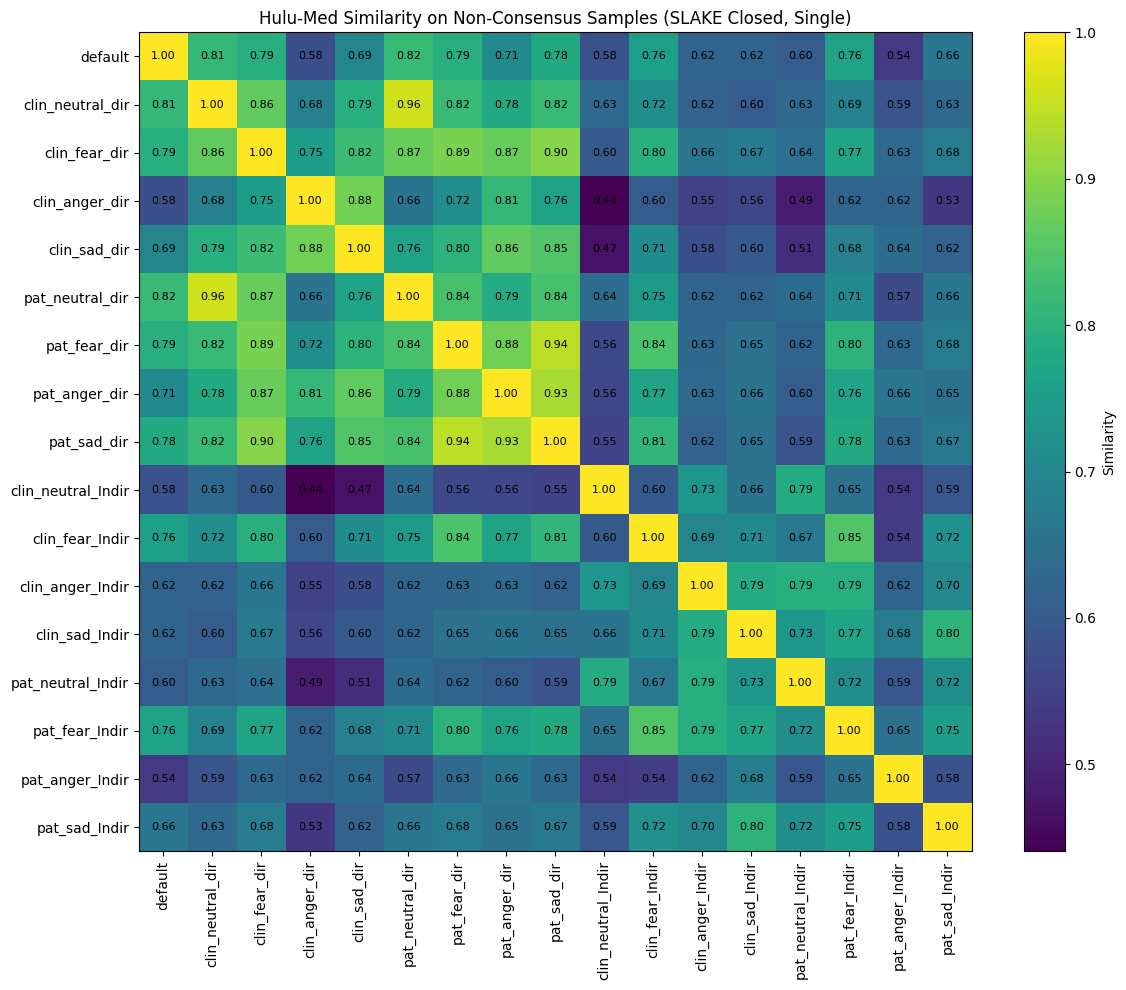

In [6]:

plot_similarity_heatmap(
    single_sim_matrix_nc,
    title="Hulu-Med Similarity on Non-Consensus Samples (SLAKE Closed, Single)",
    figsize=(12, 10),
    fontsize=8,
)


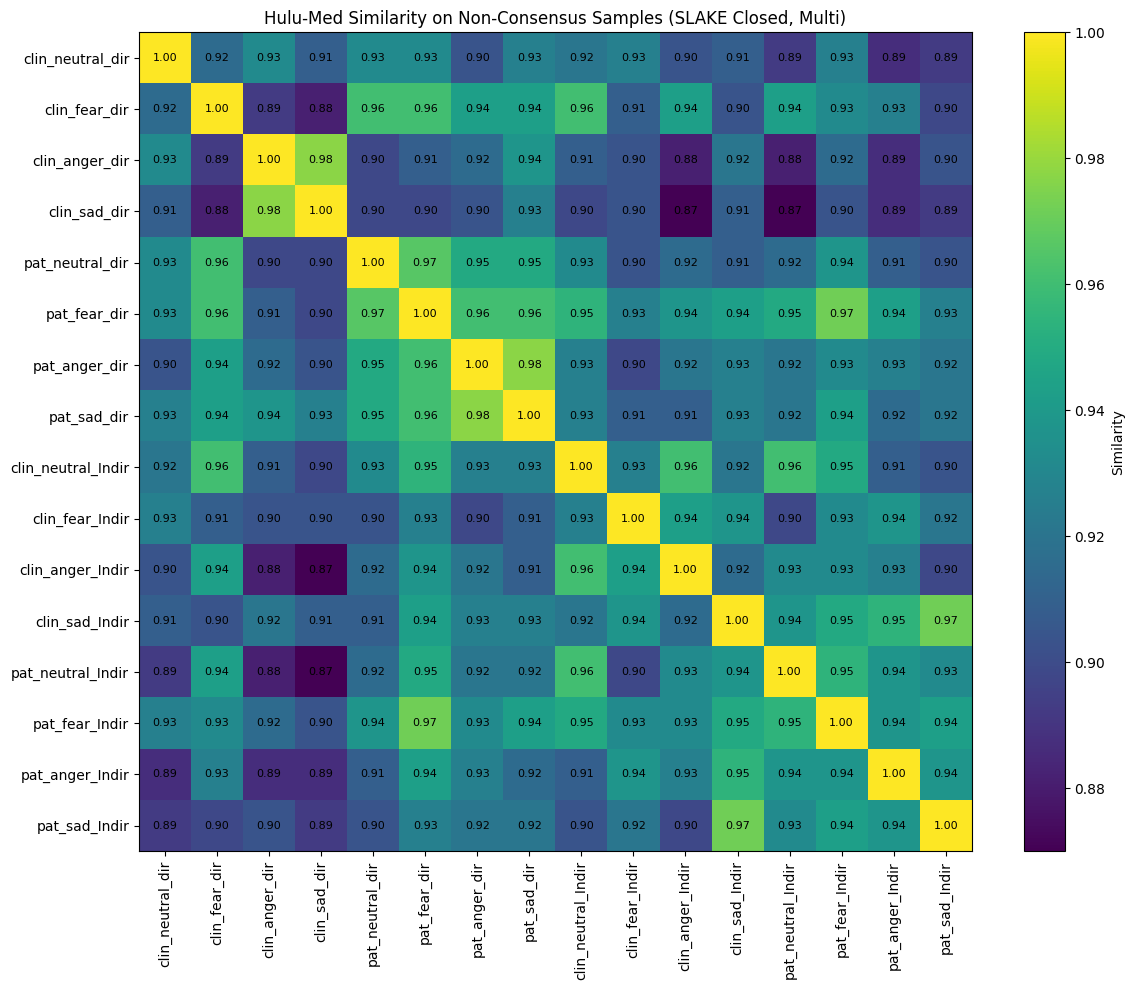

In [7]:

plot_similarity_heatmap(
    multi_sim_matrix_nc,
    title="Hulu-Med Similarity on Non-Consensus Samples (SLAKE Closed, Multi)",
    figsize=(12, 10),
    fontsize=8,
)


In [8]:

yes_bias_table = wide_table.copy()
yes_bias_table["single_yes_rate"] = yes_bias_table.apply(lambda r: yes_rate(r["single_Yes"], r["single_No"]), axis=1)
yes_bias_table["multi_yes_rate"] = yes_bias_table.apply(lambda r: yes_rate(r["multi_Yes"], r["multi_No"]), axis=1)

acc_compare_table = wide_table[["prompt", "single_Acc", "multi_Acc"]].copy()
acc_compare_table["acc_change_multi_minus_single"] = acc_compare_table["multi_Acc"] - acc_compare_table["single_Acc"]

summary_compare = pd.DataFrame({
    "metric": [
        "mean_off_diagonal_similarity",
        "mean_yes_rate",
        "mean_accuracy",
    ],
    "single": [
        round(mean_off_diagonal(single_sim_matrix_nc), 3),
        round(yes_bias_table["single_yes_rate"].mean(), 3),
        round(wide_table["single_Acc"].mean(), 3),
    ],
    "multi": [
        round(mean_off_diagonal(multi_sim_matrix_nc), 3),
        round(yes_bias_table["multi_yes_rate"].dropna().mean(), 3),
        round(wide_table["multi_Acc"].dropna().mean(), 3),
    ],
})
summary_compare["multi_minus_single"] = summary_compare["multi"] - summary_compare["single"]

family_definitions = {
    "single_direct": [p for p in row_order if p.endswith("_dir")],
    "single_indirect": [p for p in row_order if p.endswith("_Indir")],
    "multi_direct": [p for p in multi_row_order if p.endswith("_dir")],
    "multi_indirect": [p for p in multi_row_order if p.endswith("_Indir")],
}

family_rows = []
for family, prompts in family_definitions.items():
    if family.startswith("single"):
        fam_matrix = single_sim_matrix_nc.loc[prompts, prompts]
        fam_acc = wide_table.loc[wide_table["prompt"].isin(prompts), "single_Acc"]
        fam_yes = yes_bias_table.loc[yes_bias_table["prompt"].isin(prompts), "single_yes_rate"]
    else:
        fam_matrix = multi_sim_matrix_nc.loc[prompts, prompts]
        fam_acc = wide_table.loc[wide_table["prompt"].isin(prompts), "multi_Acc"]
        fam_yes = yes_bias_table.loc[yes_bias_table["prompt"].isin(prompts), "multi_yes_rate"]

    family_rows.append({
        "family": family,
        "mean_similarity": round(mean_off_diagonal(fam_matrix), 3),
        "mean_yes_rate": round(fam_yes.mean(), 3),
        "mean_accuracy": round(fam_acc.mean(), 3),
    })

family_summary = pd.DataFrame(family_rows)

print("Single mean off-diagonal similarity:", round(mean_off_diagonal(single_sim_matrix_nc), 3))
print("Multi mean off-diagonal similarity:", round(mean_off_diagonal(multi_sim_matrix_nc), 3))
print("Mean single yes-rate:", round(yes_bias_table["single_yes_rate"].mean(), 3))
print("Mean multi yes-rate:", round(yes_bias_table["multi_yes_rate"].dropna().mean(), 3))
print("Mean accuracy gain (multi - single):", round(acc_compare_table["acc_change_multi_minus_single"].dropna().mean(), 3))

summary_compare


Single mean off-diagonal similarity: 0.696
Multi mean off-diagonal similarity: 0.924
Mean single yes-rate: 0.408
Mean multi yes-rate: 0.506
Mean accuracy gain (multi - single): 0.073


,metric,single,multi,multi_minus_single
0,mean_off_diagonal_similarity,0.696,0.924,0.228
1,mean_yes_rate,0.408,0.506,0.098
2,mean_accuracy,0.788,0.856,0.068


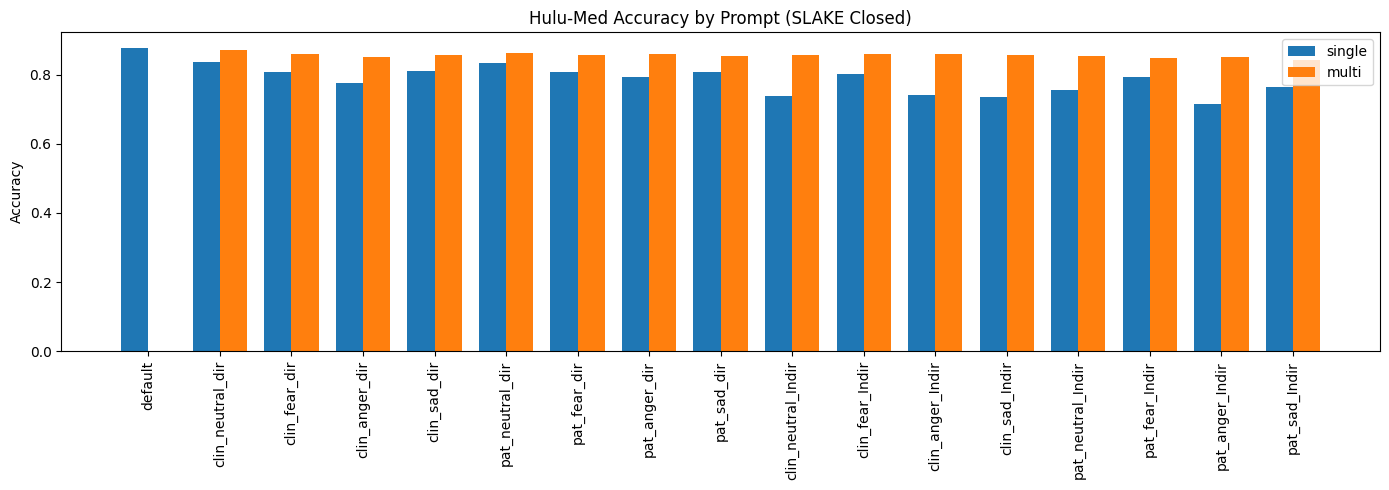

In [9]:

plot_df = wide_table.copy()
plot_df["prompt"] = plot_df["prompt"].astype(str)

x = np.arange(len(plot_df))
width = 0.38

plt.figure(figsize=(14, 5))
plt.bar(x - width / 2, plot_df["single_Acc"], width=width, label="single")
plt.bar(x + width / 2, plot_df["multi_Acc"].fillna(np.nan), width=width, label="multi")

plt.xticks(x, plot_df["prompt"], rotation=90)
plt.ylabel("Accuracy")
plt.title("Hulu-Med Accuracy by Prompt (SLAKE Closed)")
plt.legend()
plt.tight_layout()
plt.show()


### Main results

- **Mean off-diagonal similarity** increased from **0.696** in **single-turn** mode to **0.924** in **multi-turn** mode.
- **Mean yes-rate** increased from **0.408** to **0.506**.
- **Mean accuracy** increased from **0.788** to **0.856**.
- The mean accuracy gain of multi-turn prompting over single-turn prompting is **+0.068** (about **6.8 percentage points**).

### Interpretation

- **Multi-turn prompting is much more stable** across emotional prompt variants, as shown by the much higher similarity scores.
- **Single-turn prompting has a stronger No-bias**, while multi-turn prompting produces a much more balanced Yes/No distribution.
- **Multi-turn prompting is also consistently more accurate** across all comparable prompt variants.
- Overall, for Hulu-Med, the conversational multi-turn format appears to **reduce prompt sensitivity while improving accuracy** on difficult yes/no samples.

The heatmaps above further show that prompt-to-prompt agreement is much tighter in multi-turn mode than in single-turn mode.


## Direct emotion comparison

This section compares the **direct emotional prompts** only, using **single-turn** non-consensus samples.


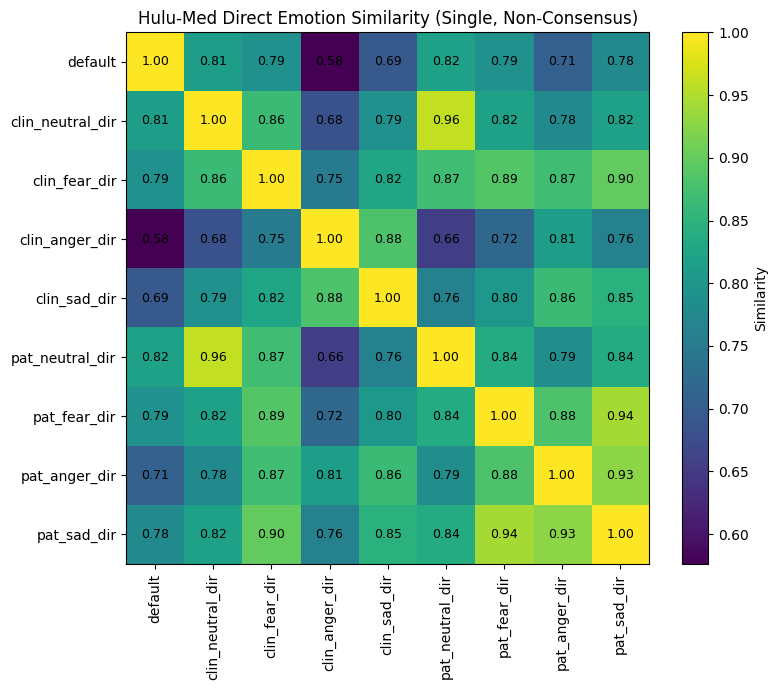

In [10]:

direct_emotion_order = [
    "default",
    "clin_neutral_dir",
    "clin_fear_dir",
    "clin_anger_dir",
    "clin_sad_dir",
    "pat_neutral_dir",
    "pat_fear_dir",
    "pat_anger_dir",
    "pat_sad_dir",
]

direct_emotion_sim_matrix = single_sim_matrix_nc.loc[direct_emotion_order, direct_emotion_order]
plot_similarity_heatmap(
    direct_emotion_sim_matrix,
    title="Hulu-Med Direct Emotion Similarity (Single, Non-Consensus)",
    figsize=(8, 7),
    fontsize=9,
)


In [11]:

direct_emotion_pairs = pd.DataFrame([
    {"comparison": "default vs clin_neutral", "similarity": direct_emotion_sim_matrix.loc["default", "clin_neutral_dir"]},
    {"comparison": "default vs pat_neutral", "similarity": direct_emotion_sim_matrix.loc["default", "pat_neutral_dir"]},
    {"comparison": "clin_fear vs clin_sad", "similarity": direct_emotion_sim_matrix.loc["clin_fear_dir", "clin_sad_dir"]},
    {"comparison": "pat_fear vs pat_sad", "similarity": direct_emotion_sim_matrix.loc["pat_fear_dir", "pat_sad_dir"]},
    {"comparison": "clin_neutral vs pat_neutral", "similarity": direct_emotion_sim_matrix.loc["clin_neutral_dir", "pat_neutral_dir"]},
    {"comparison": "clin_fear vs pat_fear", "similarity": direct_emotion_sim_matrix.loc["clin_fear_dir", "pat_fear_dir"]},
    {"comparison": "clin_anger vs pat_anger", "similarity": direct_emotion_sim_matrix.loc["clin_anger_dir", "pat_anger_dir"]},
    {"comparison": "clin_sad vs pat_sad", "similarity": direct_emotion_sim_matrix.loc["clin_sad_dir", "pat_sad_dir"]},
    {"comparison": "default vs clin_anger", "similarity": direct_emotion_sim_matrix.loc["default", "clin_anger_dir"]},
    {"comparison": "default vs pat_anger", "similarity": direct_emotion_sim_matrix.loc["default", "pat_anger_dir"]},
    {"comparison": "clin_neutral vs clin_anger", "similarity": direct_emotion_sim_matrix.loc["clin_neutral_dir", "clin_anger_dir"]},
    {"comparison": "pat_neutral vs pat_anger", "similarity": direct_emotion_sim_matrix.loc["pat_neutral_dir", "pat_anger_dir"]},
])

direct_emotion_summary = pd.DataFrame({
    "summary": [
        "default~neutral_mean",
        "fear~sad_mean",
        "matched_role_mean",
        "anger_vs_default_or_neutral_mean",
    ],
    "similarity": [
        np.mean([
            direct_emotion_sim_matrix.loc["default", "clin_neutral_dir"],
            direct_emotion_sim_matrix.loc["default", "pat_neutral_dir"],
        ]),
        np.mean([
            direct_emotion_sim_matrix.loc["clin_fear_dir", "clin_sad_dir"],
            direct_emotion_sim_matrix.loc["pat_fear_dir", "pat_sad_dir"],
        ]),
        np.mean([
            direct_emotion_sim_matrix.loc["clin_neutral_dir", "pat_neutral_dir"],
            direct_emotion_sim_matrix.loc["clin_fear_dir", "pat_fear_dir"],
            direct_emotion_sim_matrix.loc["clin_anger_dir", "pat_anger_dir"],
            direct_emotion_sim_matrix.loc["clin_sad_dir", "pat_sad_dir"],
        ]),
        np.mean([
            direct_emotion_sim_matrix.loc["default", "clin_anger_dir"],
            direct_emotion_sim_matrix.loc["default", "pat_anger_dir"],
            direct_emotion_sim_matrix.loc["clin_neutral_dir", "clin_anger_dir"],
            direct_emotion_sim_matrix.loc["pat_neutral_dir", "pat_anger_dir"],
        ]),
    ],
})

direct_emotion_pairs.round(3)


,comparison,similarity
0,default vs clin_neutral,0.814
1,default vs pat_neutral,0.819
2,clin_fear vs clin_sad,0.825
3,pat_fear vs pat_sad,0.944
4,clin_neutral vs pat_neutral,0.960
5,clin_fear vs pat_fear,0.887
6,clin_anger vs pat_anger,0.814
7,clin_sad vs pat_sad,0.847
8,default vs clin_anger,0.576
9,default vs pat_anger,0.706


## Direct emotion findings

Using the **single-turn non-consensus** samples, the direct-emotion similarity matrix shows several clear patterns:

- **Default is close to neutral**
  - `default` vs `clin_neutral_dir` = **0.814**
  - `default` vs `pat_neutral_dir` = **0.819**

- **Anger is the most distinct condition**
  - `default` vs `clin_anger_dir` = **0.576**
  - `default` vs `pat_anger_dir` = **0.706**
  - `clin_neutral_dir` vs `clin_anger_dir` = **0.684**
  - `pat_neutral_dir` vs `pat_anger_dir` = **0.785**

- **Fear is close to sadness**
  - `clin_fear_dir` vs `clin_sad_dir` = **0.825**
  - `pat_fear_dir` vs `pat_sad_dir` = **0.944**

- **Role effect is smaller than emotion effect**
  - `clin_neutral_dir` vs `pat_neutral_dir` = **0.960**
  - `clin_fear_dir` vs `pat_fear_dir` = **0.887**
  - `clin_anger_dir` vs `pat_anger_dir` = **0.814**
  - `clin_sad_dir` vs `pat_sad_dir` = **0.847**

Interpretation:

- For Hulu-Med, **emotion changes behavior more strongly than speaker role** in the direct prompt setting.
- **Anger** is the strongest behavior-shifting condition.
- **Fear** and **sadness** are more similar to each other than either is to anger.


## Indirect emotion comparison

This section compares the **indirect emotional prompts** only, using **single-turn** non-consensus samples.


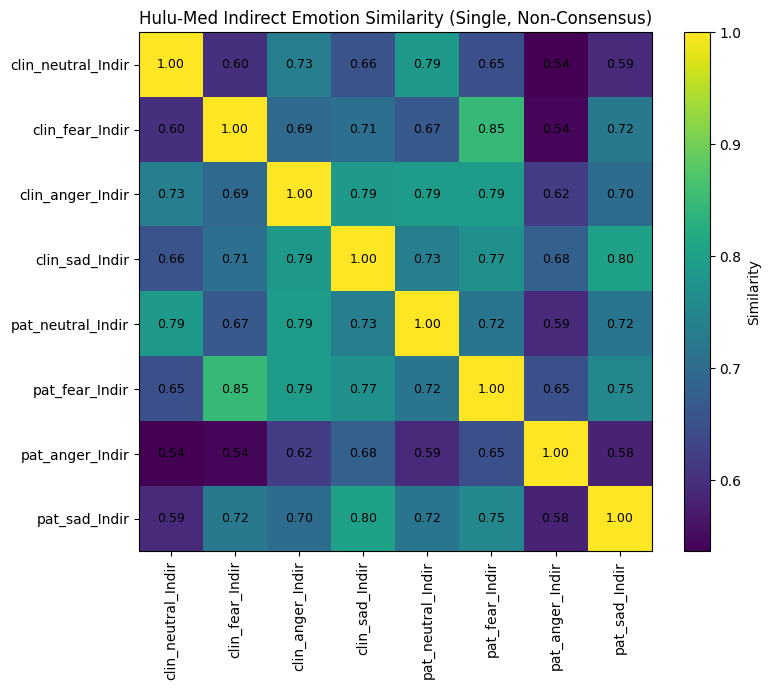

In [12]:

indirect_emotion_order = [
    "clin_neutral_Indir",
    "clin_fear_Indir",
    "clin_anger_Indir",
    "clin_sad_Indir",
    "pat_neutral_Indir",
    "pat_fear_Indir",
    "pat_anger_Indir",
    "pat_sad_Indir",
]

indirect_emotion_sim_matrix = single_sim_matrix_nc.loc[indirect_emotion_order, indirect_emotion_order]
plot_similarity_heatmap(
    indirect_emotion_sim_matrix,
    title="Hulu-Med Indirect Emotion Similarity (Single, Non-Consensus)",
    figsize=(8, 7),
    fontsize=9,
)


In [13]:

indirect_emotion_pairs = pd.DataFrame([
    {"comparison": "clin_neutral vs pat_neutral", "similarity": indirect_emotion_sim_matrix.loc["clin_neutral_Indir", "pat_neutral_Indir"]},
    {"comparison": "clin_fear vs pat_fear", "similarity": indirect_emotion_sim_matrix.loc["clin_fear_Indir", "pat_fear_Indir"]},
    {"comparison": "clin_anger vs pat_anger", "similarity": indirect_emotion_sim_matrix.loc["clin_anger_Indir", "pat_anger_Indir"]},
    {"comparison": "clin_sad vs pat_sad", "similarity": indirect_emotion_sim_matrix.loc["clin_sad_Indir", "pat_sad_Indir"]},
    {"comparison": "clin_fear vs clin_sad", "similarity": indirect_emotion_sim_matrix.loc["clin_fear_Indir", "clin_sad_Indir"]},
    {"comparison": "pat_fear vs pat_sad", "similarity": indirect_emotion_sim_matrix.loc["pat_fear_Indir", "pat_sad_Indir"]},
    {"comparison": "pat_anger vs clin_neutral", "similarity": indirect_emotion_sim_matrix.loc["pat_anger_Indir", "clin_neutral_Indir"]},
    {"comparison": "pat_anger vs clin_fear", "similarity": indirect_emotion_sim_matrix.loc["pat_anger_Indir", "clin_fear_Indir"]},
    {"comparison": "pat_anger vs pat_neutral", "similarity": indirect_emotion_sim_matrix.loc["pat_anger_Indir", "pat_neutral_Indir"]},
    {"comparison": "pat_anger vs pat_sad", "similarity": indirect_emotion_sim_matrix.loc["pat_anger_Indir", "pat_sad_Indir"]},
])

indirect_emotion_summary = pd.DataFrame({
    "summary": [
        "fear~sad_mean",
        "matched_role_mean",
        "patient_anger_vs_selected_mean",
    ],
    "similarity": [
        np.mean([
            indirect_emotion_sim_matrix.loc["clin_fear_Indir", "clin_sad_Indir"],
            indirect_emotion_sim_matrix.loc["pat_fear_Indir", "pat_sad_Indir"],
        ]),
        np.mean([
            indirect_emotion_sim_matrix.loc["clin_neutral_Indir", "pat_neutral_Indir"],
            indirect_emotion_sim_matrix.loc["clin_fear_Indir", "pat_fear_Indir"],
            indirect_emotion_sim_matrix.loc["clin_anger_Indir", "pat_anger_Indir"],
            indirect_emotion_sim_matrix.loc["clin_sad_Indir", "pat_sad_Indir"],
        ]),
        np.mean([
            indirect_emotion_sim_matrix.loc["pat_anger_Indir", "clin_neutral_Indir"],
            indirect_emotion_sim_matrix.loc["pat_anger_Indir", "clin_fear_Indir"],
            indirect_emotion_sim_matrix.loc["pat_anger_Indir", "pat_neutral_Indir"],
            indirect_emotion_sim_matrix.loc["pat_anger_Indir", "pat_sad_Indir"],
        ]),
    ],
})

indirect_emotion_pairs.round(3)


,comparison,similarity
0,clin_neutral vs pat_neutral,0.785
1,clin_fear vs pat_fear,0.847
2,clin_anger vs pat_anger,0.621
3,clin_sad vs pat_sad,0.802
4,clin_fear vs clin_sad,0.706
5,pat_fear vs pat_sad,0.751
6,pat_anger vs clin_neutral,0.537
7,pat_anger vs clin_fear,0.542
8,pat_anger vs pat_neutral,0.593
9,pat_anger vs pat_sad,0.582


## Indirect emotion findings

Using the **single-turn non-consensus** samples, the indirect-emotion similarity matrix shows a different pattern from the direct prompts:

- **Patient anger is the most distinct indirect condition**
  - `pat_anger_Indir` vs `clin_neutral_Indir` = **0.537**
  - `pat_anger_Indir` vs `clin_fear_Indir` = **0.542**
  - `pat_anger_Indir` vs `pat_neutral_Indir` = **0.593**
  - `pat_anger_Indir` vs `pat_sad_Indir` = **0.582**

- **Fear and sadness remain relatively close**
  - `clin_fear_Indir` vs `clin_sad_Indir` = **0.706**
  - `pat_fear_Indir` vs `pat_sad_Indir` = **0.751**

- **Role effect is modest for some emotions, but stronger for anger**
  - `clin_neutral_Indir` vs `pat_neutral_Indir` = **0.785**
  - `clin_fear_Indir` vs `pat_fear_Indir` = **0.847**
  - `clin_anger_Indir` vs `pat_anger_Indir` = **0.621**
  - `clin_sad_Indir` vs `pat_sad_Indir` = **0.802**

Interpretation:

- In the indirect setting, **patient anger** is the strongest behavior-shifting condition.
- **Fear** and **sadness** remain more similar to each other than to anger.
- Compared with the direct prompts, the indirect prompts suggest a stronger **role × emotion interaction**, especially for anger.

## Role comparison (clinician vs patient)

This section tests whether Hulu-Med changes its outputs when the same emotion is expressed by a **clinician** versus a **patient**.

Important note:
- **Clinician–patient yes-rate gap** is the main measure of **output difference**
- **Accuracy by emotion, role, and style** is used to check whether those output differences also affect correctness


In [14]:
emotions = ["neutral", "fear", "anger", "sad"]
role_effect_rows = []

def get_yes_rate(df, prompt, mode):
    col = "single_yes_rate" if mode == "single" else "multi_yes_rate"
    return df.loc[df["prompt"] == prompt, col].iloc[0]

def get_acc(df, prompt, mode):
    col = "single_Acc" if mode == "single" else "multi_Acc"
    return df.loc[df["prompt"] == prompt, col].iloc[0]

for emo in emotions:
    d_clin = f"clin_{emo}_dir"
    d_pat = f"pat_{emo}_dir"
    i_clin = f"clin_{emo}_Indir"
    i_pat = f"pat_{emo}_Indir"

    role_effect_rows.append({
        "emotion": emo,

        "single_direct_yes_gap": abs(get_yes_rate(yes_bias_table, d_clin, "single") - get_yes_rate(yes_bias_table, d_pat, "single")),
        "single_indirect_yes_gap": abs(get_yes_rate(yes_bias_table, i_clin, "single") - get_yes_rate(yes_bias_table, i_pat, "single")),
        "multi_direct_yes_gap": abs(get_yes_rate(yes_bias_table, d_clin, "multi") - get_yes_rate(yes_bias_table, d_pat, "multi")),
        "multi_indirect_yes_gap": abs(get_yes_rate(yes_bias_table, i_clin, "multi") - get_yes_rate(yes_bias_table, i_pat, "multi")),

        "single_direct_acc_gap": abs(get_acc(wide_table, d_clin, "single") - get_acc(wide_table, d_pat, "single")),
        "single_indirect_acc_gap": abs(get_acc(wide_table, i_clin, "single") - get_acc(wide_table, i_pat, "single")),
        "multi_direct_acc_gap": abs(get_acc(wide_table, d_clin, "multi") - get_acc(wide_table, d_pat, "multi")),
        "multi_indirect_acc_gap": abs(get_acc(wide_table, i_clin, "multi") - get_acc(wide_table, i_pat, "multi")),
    })

role_effect_table = pd.DataFrame(role_effect_rows).round(3)
role_effect_table

,emotion,single_direct_yes_gap,single_indirect_yes_gap,multi_direct_yes_gap,multi_indirect_yes_gap,single_direct_acc_gap,single_indirect_acc_gap,multi_direct_acc_gap,multi_indirect_acc_gap
0,neutral,0.014,0.034,0.034,0.020,0.003,0.017,0.011,0.002
1,fear,0.017,0.048,0.008,0.017,0.000,0.009,0.003,0.011
2,anger,0.082,0.144,0.037,0.020,0.019,0.026,0.008,0.008
3,sad,0.059,0.065,0.020,0.003,0.003,0.031,0.002,0.014


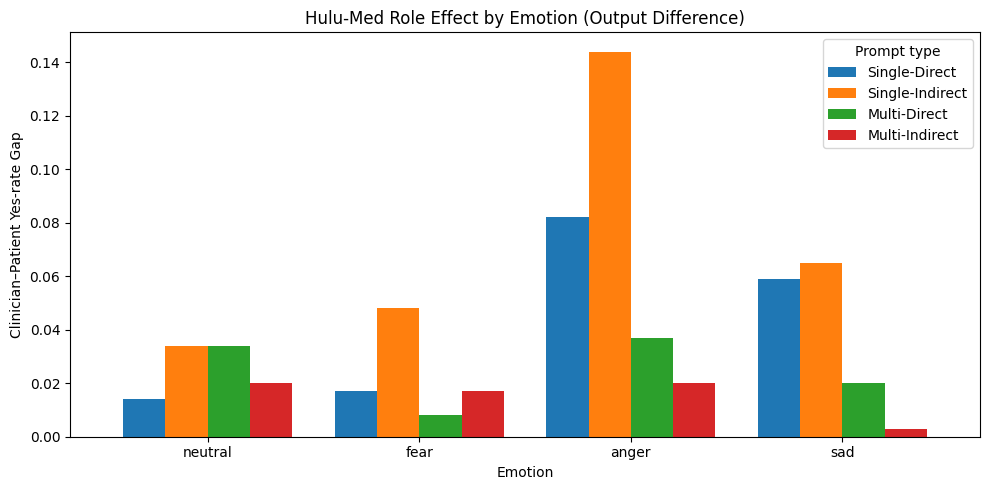

In [15]:
role_yes_plot_df = role_effect_table.set_index("emotion")[[
    "single_direct_yes_gap",
    "single_indirect_yes_gap",
    "multi_direct_yes_gap",
    "multi_indirect_yes_gap",
]].rename(columns={
    "single_direct_yes_gap": "Single-Direct",
    "single_indirect_yes_gap": "Single-Indirect",
    "multi_direct_yes_gap": "Multi-Direct",
    "multi_indirect_yes_gap": "Multi-Indirect",
})

ax = role_yes_plot_df.plot(kind="bar", figsize=(10, 5), width=0.8)

ax.set_xlabel("Emotion")
ax.set_ylabel("Clinician–Patient Yes-rate Gap")
ax.set_title("Hulu-Med Role Effect by Emotion (Output Difference)")
ax.set_xticklabels(role_yes_plot_df.index, rotation=0)
ax.legend(title="Prompt type")

plt.tight_layout()
plt.show()

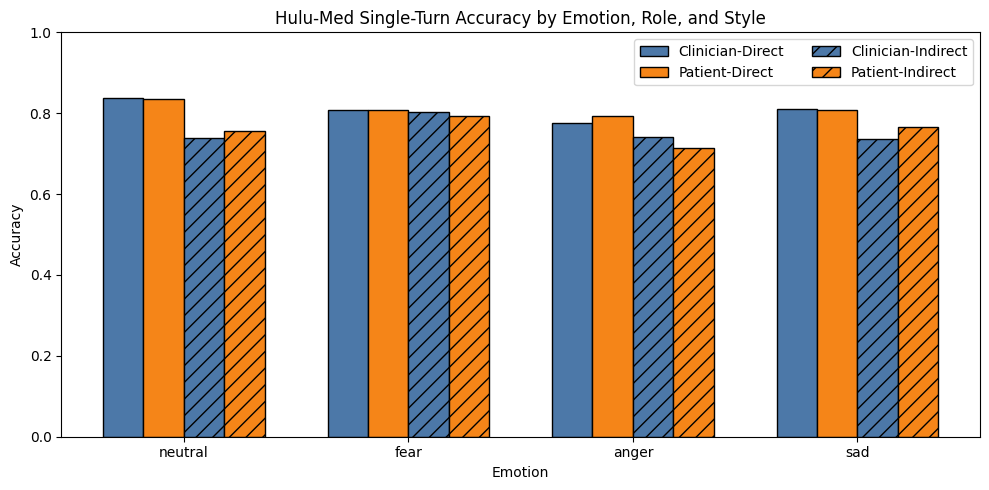

In [16]:
import numpy as np
import matplotlib.pyplot as plt

emotions = ["neutral", "fear", "anger", "sad"]

single_role_plot = []
for emo in emotions:
    single_role_plot.append({
        "emotion": emo,
        "clin_direct": wide_table.loc[wide_table["prompt"] == f"clin_{emo}_dir", "single_Acc"].iloc[0],
        "pat_direct": wide_table.loc[wide_table["prompt"] == f"pat_{emo}_dir", "single_Acc"].iloc[0],
        "clin_indirect": wide_table.loc[wide_table["prompt"] == f"clin_{emo}_Indir", "single_Acc"].iloc[0],
        "pat_indirect": wide_table.loc[wide_table["prompt"] == f"pat_{emo}_Indir", "single_Acc"].iloc[0],
    })

single_role_df = pd.DataFrame(single_role_plot).set_index("emotion")

x = np.arange(len(single_role_df.index))
width = 0.18

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(x - 1.5*width, single_role_df["clin_direct"], width=width,
       label="Clinician-Direct", color="#4C78A8", edgecolor="black")
ax.bar(x - 0.5*width, single_role_df["pat_direct"], width=width,
       label="Patient-Direct", color="#F58518", edgecolor="black")
ax.bar(x + 0.5*width, single_role_df["clin_indirect"], width=width,
       label="Clinician-Indirect", color="#4C78A8", edgecolor="black", hatch="//")
ax.bar(x + 1.5*width, single_role_df["pat_indirect"], width=width,
       label="Patient-Indirect", color="#F58518", edgecolor="black", hatch="//")

ax.set_xticks(x)
ax.set_xticklabels(single_role_df.index, rotation=0)
ax.set_xlabel("Emotion")
ax.set_ylabel("Accuracy")
ax.set_title("Hulu-Med Single-Turn Accuracy by Emotion, Role, and Style")
ax.set_ylim(0, 1.0)
ax.legend(ncol=2)

plt.tight_layout()
plt.show()

## Role comparison findings

This section asks whether Hulu-Med changes its outputs when the same emotion is expressed by a **clinician** versus a **patient**.

We use two complementary views:

- **Clinician–patient yes-rate gap** to measure **output difference**
- **Accuracy by emotion, role, and style** to measure whether those differences also affect correctness

### Main observations

- **Anger shows the strongest role effect**
  - single direct yes-gap = **0.082**
  - single indirect yes-gap = **0.144**
  - multi direct yes-gap = **0.037**
  - multi indirect yes-gap = **0.020**

- **Sadness shows a moderate role effect**
  - single direct yes-gap = **0.059**
  - single indirect yes-gap = **0.065**
  - multi direct yes-gap = **0.020**
  - multi indirect yes-gap = **0.003**

- **Neutral** and **fear** show relatively small role differences overall
  - neutral gaps range from **0.014** to **0.034**
  - fear gaps range from **0.008** to **0.048**

- The **accuracy differences are much smaller** than the yes-rate differences
  - this means role changes the model’s **answer tendency** more than its overall correctness

### Interpretation

- For Hulu-Med, the **speaker role does affect the output distribution**, but this effect is concentrated mainly in **anger**, especially in the **single-turn indirect** setting.
- In contrast, **accuracy is much less sensitive to role** than the Yes/No output tendency.
- Multi-turn prompting again reduces this role effect, making clinician and patient outputs more similar.

## Direct vs indirect comparison

This section compares **expression style** directly, holding **role** and **emotion** fixed.

Important note:
- **Similarity** values come from **single/multi non-consensus samples**
- **Accuracy** and **yes-rate** values are computed on **all SLAKE closed samples**


In [17]:

direct_indirect_rows = []
for role_prefix in ["clin", "pat"]:
    for emo in emotions:
        direct_prompt = f"{role_prefix}_{emo}_dir"
        indirect_prompt = f"{role_prefix}_{emo}_Indir"

        direct_indirect_rows.append({
            "condition": f"{role_prefix}_{emo}",
            "single_similarity": single_sim_matrix_nc.loc[direct_prompt, indirect_prompt],
            "multi_similarity": multi_sim_matrix_nc.loc[direct_prompt, indirect_prompt],
            "single_acc_direct": get_metric(wide_table, direct_prompt, "single_Acc"),
            "single_acc_indirect": get_metric(wide_table, indirect_prompt, "single_Acc"),
            "single_acc_change_indirect_minus_direct": get_metric(wide_table, indirect_prompt, "single_Acc") - get_metric(wide_table, direct_prompt, "single_Acc"),
            "multi_acc_direct": get_metric(wide_table, direct_prompt, "multi_Acc"),
            "multi_acc_indirect": get_metric(wide_table, indirect_prompt, "multi_Acc"),
            "multi_acc_change_indirect_minus_direct": get_metric(wide_table, indirect_prompt, "multi_Acc") - get_metric(wide_table, direct_prompt, "multi_Acc"),
            "single_yes_rate_direct": yes_rate(get_metric(wide_table, direct_prompt, "single_Yes"), get_metric(wide_table, direct_prompt, "single_No")),
            "single_yes_rate_indirect": yes_rate(get_metric(wide_table, indirect_prompt, "single_Yes"), get_metric(wide_table, indirect_prompt, "single_No")),
            "multi_yes_rate_direct": yes_rate(get_metric(wide_table, direct_prompt, "multi_Yes"), get_metric(wide_table, direct_prompt, "multi_No")),
            "multi_yes_rate_indirect": yes_rate(get_metric(wide_table, indirect_prompt, "multi_Yes"), get_metric(wide_table, indirect_prompt, "multi_No")),
        })

direct_indirect_compare_table = pd.DataFrame(direct_indirect_rows)
direct_indirect_compare_table.round(3)


,condition,single_similarity,multi_similarity,single_acc_direct,single_acc_indirect,single_acc_change_indirect_minus_direct,multi_acc_direct,multi_acc_indirect,multi_acc_change_indirect_minus_direct,single_yes_rate_direct,single_yes_rate_indirect,multi_yes_rate_direct,multi_yes_rate_indirect
0,clin_neutral,0.633,0.921,0.837,0.738,-0.099,0.873,0.856,-0.017,0.442,0.479,0.479,0.501
1,clin_fear,0.797,0.910,0.808,0.803,-0.005,0.859,0.859,0.000,0.408,0.476,0.504,0.493
2,clin_anger,0.548,0.881,0.775,0.741,-0.034,0.851,0.859,0.008,0.285,0.414,0.485,0.493
3,clin_sad,0.599,0.910,0.811,0.735,-0.076,0.856,0.856,0.000,0.344,0.369,0.496,0.518
4,pat_neutral,0.638,0.915,0.834,0.755,-0.079,0.862,0.854,-0.008,0.456,0.445,0.513,0.521
5,pat_fear,0.802,0.972,0.808,0.794,-0.014,0.856,0.848,-0.008,0.425,0.428,0.513,0.510
6,pat_anger,0.661,0.927,0.794,0.715,-0.079,0.859,0.851,-0.008,0.366,0.270,0.521,0.513
7,pat_sad,0.667,0.921,0.808,0.766,-0.042,0.854,0.842,-0.012,0.403,0.434,0.515,0.521


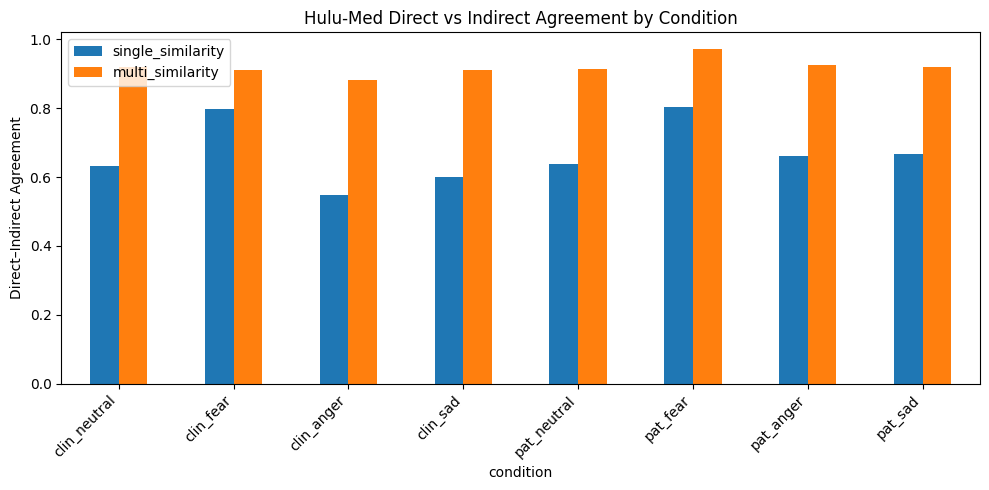

In [18]:
style_plot_df = direct_indirect_compare_table.set_index("condition")[["single_similarity", "multi_similarity"]]

ax = style_plot_df.plot(kind="bar", figsize=(10, 5))
ax.set_ylabel("Direct–Indirect Agreement")
ax.set_title("Hulu-Med Direct vs Indirect Agreement by Condition")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()


## Direct vs indirect findings

This section compares **expression style** directly, while holding **role** and **emotion** fixed.

Here, higher similarity means that the model behaves more similarly when the same condition is phrased **directly** versus **indirectly**. Lower similarity means expression style has a stronger effect.

### Main observations

- **Direct vs indirect differences are much larger in single-turn mode**
  - single similarities range from about **0.548** to **0.802**
  - multi similarities range from about **0.881** to **0.972**

- The **largest single-turn direct-vs-indirect shifts** appear for:
  - `clin_anger` = **0.548**
  - `clin_sad` = **0.599**
  - `clin_neutral` = **0.633**

- The **most stable single-turn condition** is:
  - `pat_fear` = **0.802**

- In **multi-turn mode**, all matched direct/indirect pairs are much more similar:
  - values are consistently above **0.88**
  - the highest similarity appears for `pat_fear` = **0.972**

### Accuracy observations

- In **single-turn mode**, indirect phrasing usually reduces accuracy relative to direct phrasing.
- The largest single-turn drops appear for:
  - `clin_neutral`: **-0.099**
  - `pat_anger`: **-0.079**
  - `clin_sad`: **-0.076**

- In **multi-turn mode**, the direct-vs-indirect accuracy differences are much smaller.

### Interpretation

- For Hulu-Med, **expression style matters substantially in single-turn prompting**.
- Indirect phrasing changes behavior much more in **single-turn** than in **multi-turn** mode.
- Multi-turn prompting again acts as a stabilizer, making direct and indirect prompt variants behave much more similarly.

# Key findings

This notebook analyzed **Hulu-Med** on **SLAKE closed yes/no questions** using the **raw closed files**.

## 1. Prompt sensitivity is substantial
- Out of **355** closed SLAKE samples, **177** were **non-consensus** across prompt variants.
- This means nearly **half of the samples** changed behavior under different prompt conditions.

## 2. Multi-turn prompting is much more stable than single-turn prompting
- Mean off-diagonal similarity increased from **0.696** in **single-turn** mode to **0.924** in **multi-turn** mode.
- This indicates that multi-turn prompting makes the model much less sensitive to prompt variation.

## 3. Multi-turn prompting also improves performance
- Mean accuracy increased from **0.788** to **0.856**.
- The average gain is about **+0.068**.
- Multi-turn prompting also reduced the strong **No-bias** seen in single-turn mode:
  - mean yes-rate increased from **0.408** to **0.506**

## 4. Emotion matters more than role in the direct setting
From the **direct single-turn emotion analysis**:
- **Default is close to neutral**
- **Anger is the most distinct condition**
- **Fear and sadness are relatively close**
- **Clinician vs patient** differences are generally smaller than emotion differences

## 5. In the indirect setting, patient anger is especially disruptive
From the **indirect single-turn emotion analysis**:
- **Patient anger** is the strongest behavior-shifting condition
- **Fear** and **sadness** remain relatively close
- Role interacts more strongly with emotion in indirect prompts, especially for anger

## 6. Role mainly changes output tendency, not correctness
- The **clinician–patient yes-rate gap** is largest for **anger**, especially in **single-turn indirect** prompts
- However, **accuracy gaps are small overall**
- This suggests that role changes **how the model answers** more than whether the answer is correct

## 7. Direct vs indirect phrasing matters mainly in single-turn mode
- Direct vs indirect similarity is much lower in **single-turn** mode than in **multi-turn** mode
- Indirect phrasing usually reduces accuracy relative to direct phrasing in single-turn mode
- In multi-turn mode, direct and indirect variants behave much more similarly

## Overall interpretation

For Hulu-Med, **psychological perturbations clearly affect model behavior**, especially in **single-turn prompting**.  
Among the tested factors:

- **Conversation format** has the strongest stabilizing effect
- **Emotion** has a larger effect than **speaker role**
- **Anger** is the most behavior-shifting emotional condition
- **Indirect phrasing** amplifies perturbation effects in single-turn mode
- **Multi-turn prompting** consistently reduces sensitivity and improves accuracy

Overall, Hulu-Med appears **substantially susceptible to emotional and framing effects in single-turn interaction**, while **multi-turn prompting mitigates much of this instability**.

To refresh the figures after any edits, rerun the cells in the final two sections.
